In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Exploratory Data Analysis (EDA)

In [2]:
df = pd.read_csv(r"C:\Users\lenovo\Desktop\ML project\ai_resume_screening.csv")

In [3]:
df.head()

,years_experience,skills_match_score,education_level,project_count,resume_length,github_activity,shortlisted
0,6,84.7,Bachelors,7,234,158,No
1,3,59.1,Masters,5,502,77,No
2,12,100.0,Masters,12,753,381,Yes
3,14,66.8,High School,8,529,407,Yes
4,10,99.6,Bachelors,10,754,331,Yes


In [4]:
df.isna().sum()

years_experience      0
skills_match_score    0
education_level       0
project_count         0
resume_length         0
github_activity       0
shortlisted           0
dtype: int64

In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
df = df.drop_duplicates()

In [7]:
df.describe()

,years_experience,skills_match_score,project_count,resume_length,github_activity
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000
mean,7.506567,73.682653,10.646267,572.584700,325.260667
std,4.624104,16.765909,4.634047,178.709918,159.951803
min,0.000000,0.500000,0.000000,150.000000,0.000000
25%,3.750000,62.100000,7.000000,441.000000,202.000000
50%,7.000000,74.300000,10.000000,574.000000,321.000000
75%,12.000000,86.500000,14.000000,709.000000,443.000000
max,15.000000,100.000000,25.000000,900.000000,842.000000


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   years_experience    30000 non-null  int64  
 1   skills_match_score  30000 non-null  float64
 2   education_level     30000 non-null  object 
 3   project_count       30000 non-null  int64  
 4   resume_length       30000 non-null  int64  
 5   github_activity     30000 non-null  int64  
 6   shortlisted         30000 non-null  object 
dtypes: float64(1), int64(4), object(2)
memory usage: 1.6+ MB


In [9]:
df.shape[0],df.shape[1]

(30000, 7)

# Encoding

In [10]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df["shortlisted"] = le.fit_transform(df["shortlisted"])
df["education_level"] = le.fit_transform(df["education_level"])
df.head()

,years_experience,skills_match_score,education_level,project_count,resume_length,github_activity,shortlisted
0,6,84.7,0,7,234,158,0
1,3,59.1,2,5,502,77,0
2,12,100.0,2,12,753,381,1
3,14,66.8,1,8,529,407,1
4,10,99.6,0,10,754,331,1


# Feature Scalling

In [11]:
from sklearn.preprocessing import StandardScaler
features = ["years_experience",	"skills_match_score",	"education_level",	"project_count", "resume_length", "github_activity"]
df_copy = df.copy()
scaler = StandardScaler()
df_copy[features] = scaler.fit_transform(df[features])

# Splitting Features, Train and Test

In [12]:
from sklearn.model_selection import train_test_split

x = df_copy[features]
y = df_copy["shortlisted"]

x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Model Training and Comparison

In [13]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "KNN": KNeighborsClassifier(),
    "SVM": SVC(),
    "XGBoost": XGBClassifier(
        random_state=42,
        eval_metric="logloss"
    )
}

results = []

for name, model in models.items():
    model.fit(x_train, y_train)
    y_pred = model.predict(x_test)

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred)
    })

results_df = pd.DataFrame(results)

results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.902667,0.927303,0.933938,0.930608
1,Decision Tree,0.861833,0.900095,0.902456,0.901274
2,Random Forest,0.900000,0.922011,0.936084,0.928994
3,KNN,0.895167,0.921078,0.929645,0.925341
4,SVM,0.905333,0.925569,0.940138,0.932797
5,XGBoost,0.900167,0.920843,0.937753,0.929221


# Cross Validation

In [14]:
from sklearn.model_selection import cross_val_score

cv_results = []

for name, model in models.items():
    scores = cross_val_score(
        model,
        x_train,
        y_train,
        cv=5,
        scoring="f1"
    )

    cv_results.append({
        "Model": name,
        "Mean F1 Score": scores.mean(),
        "Std F1 Score": scores.std()
    })

cv_df = pd.DataFrame(cv_results)

cv_df.sort_values("Mean F1 Score", ascending=False)

,Model,Mean F1 Score,Std F1 Score
4,SVM,0.934548,0.002774
0,Logistic Regression,0.932420,0.003083
2,Random Forest,0.931123,0.003023
5,XGBoost,0.929745,0.003087
3,KNN,0.923759,0.001796
1,Decision Tree,0.903343,0.003277


# Hyperparameter Tuning

In [15]:
from sklearn.model_selection import GridSearchCV

xgb = XGBClassifier(
    random_state=42,
    eval_metric="logloss"
)

param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [3, 5],
    "learning_rate": [0.01, 0.1],
    "subsample": [0.8, 1.0]
}

grid_search = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

grid_search.fit(x_train, y_train)

print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest Cross Validation F1 Score:")
print(grid_search.best_score_)

Best Parameters:
{'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}

Best Cross Validation F1 Score:
0.936065809922354


# Final Model Evaluation

In [16]:
best_model = grid_search.best_estimator_

y_pred = best_model.predict(x_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

Accuracy: 0.9066666666666666
Precision: 0.9275123558484349
Recall: 0.9398998330550918
F1 Score: 0.9336650082918739


# Model Evaluation

Classification Report
              precision    recall  f1-score   support

           0       0.86      0.83      0.84      1807
           1       0.93      0.94      0.93      4193

    accuracy                           0.91      6000
   macro avg       0.89      0.88      0.89      6000
weighted avg       0.91      0.91      0.91      6000



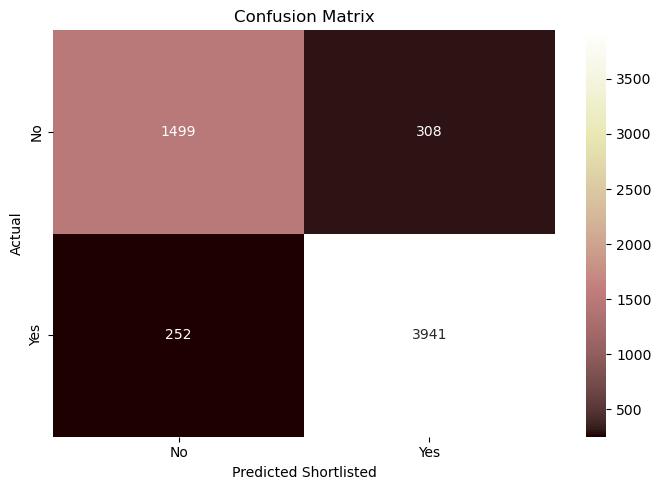

In [17]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

print("Classification Report")
print(classification_report(y_test, y_pred))

conf_matrix = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5))

sns.heatmap(
    conf_matrix,
    annot=True,
    fmt="d",
    cmap="pink",
    xticklabels=["No", "Yes"],
    yticklabels=["No", "Yes"]
)

plt.xlabel("Predicted Shortlisted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

# Feature Importance

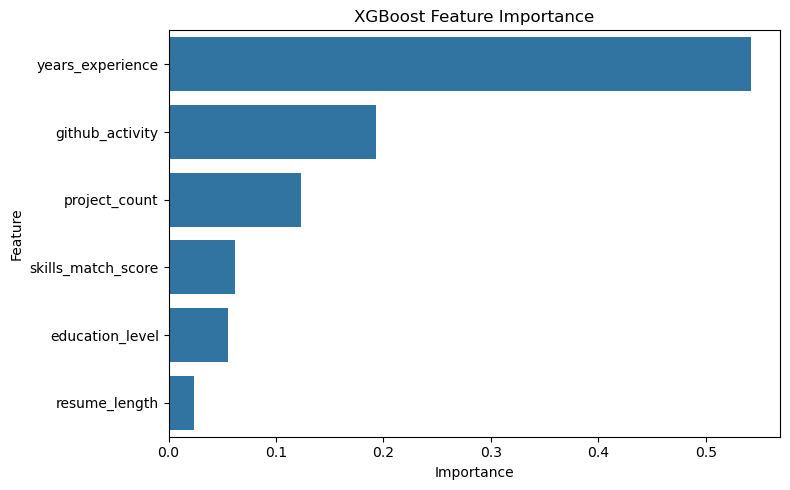

In [18]:
importance_df = pd.DataFrame({
    "Feature": features,
    "Importance": best_model.feature_importances_
})

importance_df = importance_df.sort_values(
    "Importance",
    ascending=False
)

importance_df
plt.figure(figsize=(8, 5))

sns.barplot(
    data=importance_df,
    x="Importance",
    y="Feature"
)

plt.title("XGBoost Feature Importance")
plt.tight_layout()
plt.show()

# Error Analysis

In [19]:
error_df = x_test.copy()

error_df["Actual"] = y_test.values
error_df["Predicted"] = y_pred

errors = error_df[
    error_df["Actual"] != error_df["Predicted"]
]

print("Total Predictions:", len(error_df))
print("Total Errors:", len(errors))
print("Error Rate:", len(errors) / len(error_df))

false_positives = error_df[
    (error_df["Actual"] == 0) &
    (error_df["Predicted"] == 1)
]

false_negatives = error_df[
    (error_df["Actual"] == 1) &
    (error_df["Predicted"] == 0)
]

print("False Positives:", len(false_positives))
print("False Negatives:", len(false_negatives))

Total Predictions: 6000
Total Errors: 560
Error Rate: 0.09333333333333334
False Positives: 308
False Negatives: 252


# Save the Model

In [20]:
import joblib

joblib.dump(best_model, "resume_model.pkl")
joblib.dump(scaler, "scaler.pkl")

print("Model and scaler saved successfully.")

Model and scaler saved successfully.
